# 2D bending-magnet END in the s-y (longitudinal) plane: fringe feasibility + end-shaping design

The transverse cross-section (x-y) is treated in
[`hodograph_feasibility_2d.ipynb`](hodograph_feasibility_2d.ipynb). Here $s$ is the beam
direction and $y$ the gap; this is the **longitudinal** plane where the magnet **ends** and the
**fringe field** lives (the home of pole-end / Rogowski design). Half-model, mid-plane symmetry
at $y=0$, half-gap $h$.

**Forward 2D s-y is an OPEN-boundary problem.** The flux return of a dipole is *out of this
plane* (through the x-y yoke), so in a pure s-y slice the flux escapes and the
effective-length integral is **log-divergent** — a $\phi=0$ air box gives a box-*dependent*
fringe (verified). We therefore split the work:

1. **Fringe feasibility (hodograph inverse, box-free).** Demand the longitudinal fringe and
   read off the field; the pole *face* is an equipotential. Feasibility
   $d>d^\*=(2/\pi)h\approx0.64h$ bounds how sharp the fringe (Enge edge) can be.
2. **End-shaping design (forward FEM optimization).** The pole *end* is a **free termination**,
   not an equipotential. A square end is singular ($|B|\sim r^{-1/3}$, a saturation hot spot);
   we **optimize the end chamfer** to drive the peak pole-face field to $B_0$ — numerically
   recovering the classic **Rogowski** electrode. The peak field is *local*, hence box/mesh
   convergent (unlike the effective length).

Compute lives in [`hodograph_bending_sy.py`](hodograph_bending_sy.py).


In [1]:
import os, sys, platform, datetime
import numpy as np
sys.path.insert(0, os.getcwd())
import hodograph_bending_sy as hb
from IPython.display import Image, display

print(f"gap h = {hb.H}, demanded fringe width d = {hb.D}, field edge s0 = {hb.S0}")
print(f"feasibility boundary d* = (2/pi) h = {hb.d_star():.4f}")

gap h = 1.0, demanded fringe width d = 0.9, field edge s0 = 0.0
feasibility boundary d* = (2/pi) h = 0.6366


## 1. Fringe feasibility (hodograph inverse, box-free)

Demand $B_y(s,0)=g(s)=\tfrac12(1-\tanh((s-s_0)/d))$ (flat $B_0$ inside, $\to0$ outside; edge
width $d$). The current-free continuation $g(w)$, $w=s+iy$, has its nearest singularity at
$y=\pi d/2$, so the fringe is realizable by an iron pole at gap $h$ only if $\pi d/2>h$, i.e.
$d>d^\*=(2/\pi)h$. This is a **harmonic-analysis** (Cauchy–Kovalevskaya) bound — not a limit
line (passive iron stays elliptic). The pole *face* is the equipotential $\{\phi=-h\}$; an
independent `ngsolve` manufactured-solution FEM verifies it (box-free).

In [2]:
tab = hb.feasibility_table([1.4, 1.0, 0.8, hb.d_star(), 0.5, 0.35])
print(f"{'edge d':>8}{'singularity pi*d/2':>22}{'vs gap h=1':>14}{'verdict':>14}")
for r in tab:
    print(f"{r['d']:>8.3f}{r['y_sing']:>22.3f}{'above' if r['feasible'] else 'below':>14}"
          f"{'FEASIBLE' if r['feasible'] else 'INFEASIBLE':>14}")

  edge d    singularity pi*d/2    vs gap h=1       verdict
   1.400                 2.199         above      FEASIBLE
   1.000                 1.571         above      FEASIBLE
   0.800                 1.257         above      FEASIBLE
   0.637                 1.000         below    INFEASIBLE
   0.500                 0.785         below    INFEASIBLE
   0.350                 0.550         below    INFEASIBLE


In [3]:
res = hb.fem_verify_sy(order=4)
print(f"feasible d={res['d']} (d*={res['d_star']:.3f})")
print(f"(a) interior B_y(s,0) vs demanded g(s)   : max rel err = {res['By_rel_err']*100:.3f} % of B0")
print(f"(b) FEM phi vs analytic phi (L2)         : {res['phi_L2_err']:.2e}")
print(f"(c) FEM pole-face equipotential vs read-off: max |dy| = {res['pole_match_err']:.2e}")

feasible d=0.9 (d*=0.637)
(a) interior B_y(s,0) vs demanded g(s)   : max rel err = 0.010 % of B0
(b) FEM phi vs analytic phi (L2)         : 3.30e-09
(c) FEM pole-face equipotential vs read-off: max |dy| = 1.10e-06


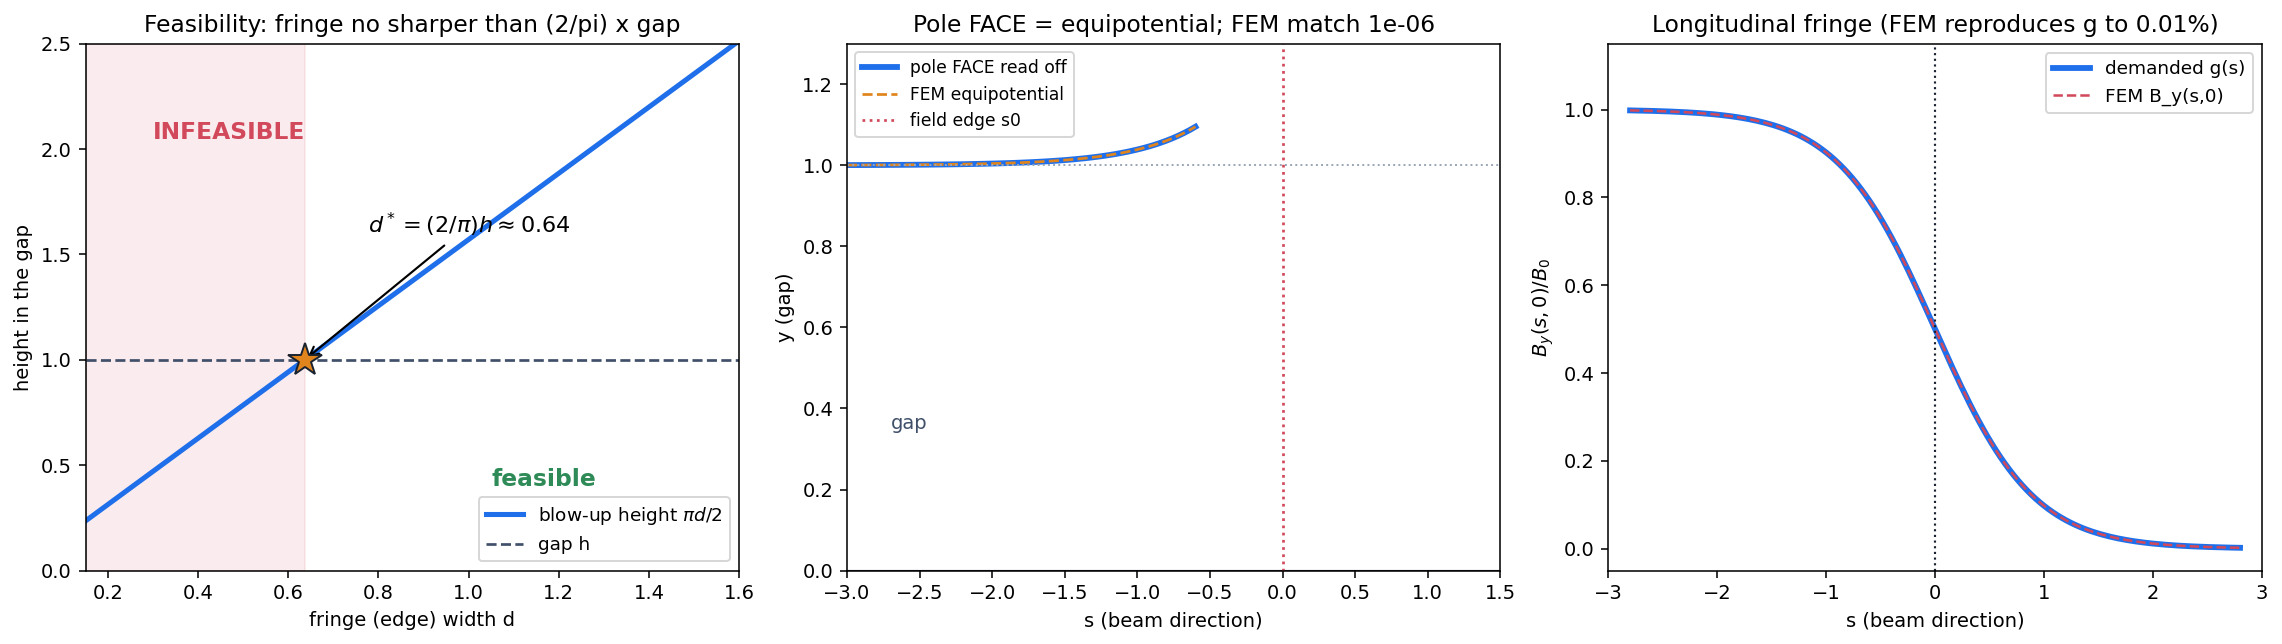

In [4]:
display(Image(filename=hb.figure_fringe(res, "hodograph_bending_sy_fringe.png")))

## 2. End-shaping design: optimize the chamfer, recover Rogowski

The pole *end* is a free termination. A **square** end has a reentrant $270^\circ$ air corner
$\Rightarrow |B|\sim r^{-1/3}\to\infty$ (a saturation hot spot). Parametrize the end as a
forward quarter-ellipse chamfer ($a$ = chamfer length, $b$ = rise) and **minimize the peak
pole-face $|B|$** by a forward FEM sweep. The peak is a *local* quantity, so it is
box/mesh-convergent even though the effective length is log-divergent. The optimum drives the
peak to $B_0$ (no enhancement) — the classic **Rogowski** result, recovered numerically without
conformal algebra.

In [5]:
cur = hb.design_curve()   # peak |B|/B0 vs chamfer length a (rise b = gap)
print("chamfer length a [gap]:", cur["avals"])
print("peak |B|/B0           :", [round(p, 3) for p in cur["peaks"]])
print(f"square end -> inf;  best (a={cur['best_a']}) peak = {cur['best_peak']:.3f}"
      f"  (Rogowski limit B0 = 1.000)")

chamfer length a [gap]: [0.4, 0.8, 1.4, 2.2, 3.2, 4.4]
peak |B|/B0           : [1.709, 1.321, 1.13, 1.053, 1.025, 1.013]
square end -> inf;  best (a=4.4) peak = 1.013  (Rogowski limit B0 = 1.000)


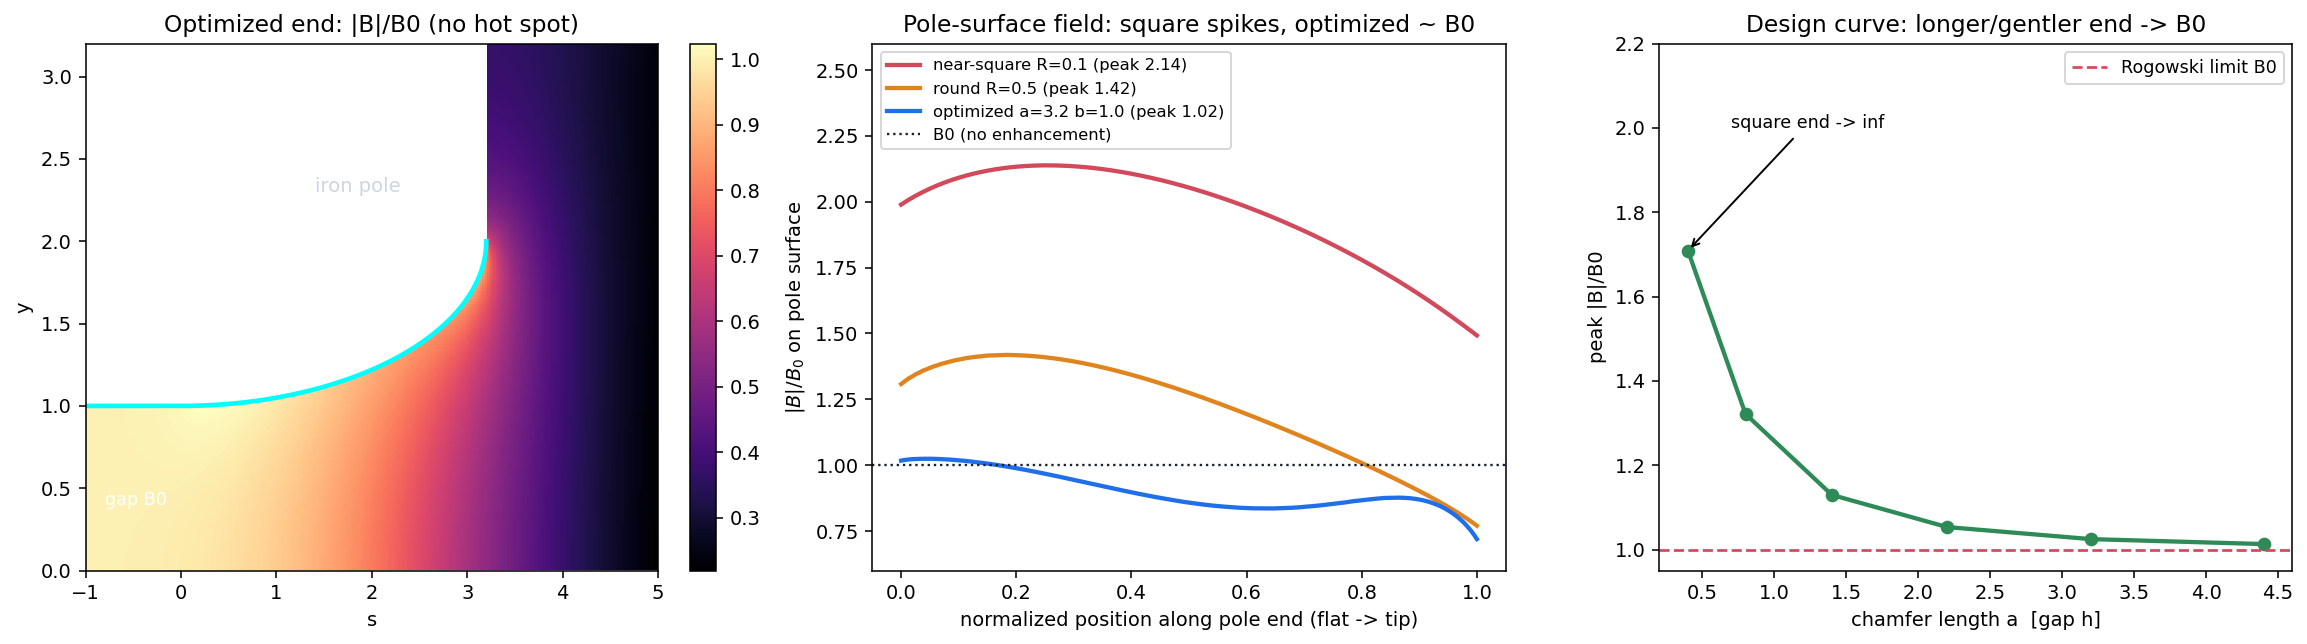

In [6]:
display(Image(filename=hb.figure_design(cur, "hodograph_bending_sy_design.png")))

## 3. Honest scope

* **Box-free where it matters.** (1) the fringe feasibility is the analytic continuation of the
  demand (no box); (2) the design target is the *peak pole-face field*, a **local** quantity that
  is box/mesh-convergent (verified: R=0.3 round peak stable to ~1e-2 from 6→12-gap boxes).
* **The effective length / EFB is log-divergent in 2D** ($g\sim1/s$, $\int B_y\,ds$ diverges) —
  genuine open-boundary physics (the flux return is out-of-plane). The finite EFB is a 3D /
  finite-magnet quantity; the 2D END design targets **no field enhancement**, not $L_{\rm eff}$.
* The numerical chamfer optimum **is** the classic Rogowski electrode ($|B|=B_0$): a low-novelty
  but correct result, here obtained by a robust FEM-in-the-loop search that generalizes to
  arbitrary gaps and tilted ends where the closed form is awkward.

In [7]:
def _ver(m):
    try:
        return __import__(m).__version__
    except Exception:
        return None

payload = {
    "generated_at_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "radia_version": _ver("radia"), "ngsolve_version": _ver("ngsolve"),
    "python_version": platform.python_version(), "platform": platform.platform(),
    "gap_h": hb.H, "edge_d": hb.D, "s0": hb.S0, "d_star": float(hb.d_star()),
    "feasibility_table": hb.feasibility_table([1.4, 1.0, 0.8, hb.d_star(), 0.5, 0.35]),
    "fem_verify": {k: v for k, v in res.items() if not k.startswith("_")},
    "design_curve": cur,
}
print("result summary  (d*=%.4f, By rel err %.3f%%; design best peak %.3f)"
      % (payload["d_star"], res["By_rel_err"]*100, cur["best_peak"]))


result summary  (d*=0.6366, By rel err 0.010%; design best peak 1.013)


## Numerical evidence

Checked values are stored in `validation_test/clebsch_hodograph/hodograph_bending_sy.json`. This executed notebook embeds the public result and does not write a docs-local JSON sidecar.